In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

SWDA.MI #iShares Core MSCI World UCITS ETF
AGGH.MI #iShares Core Global Aggregate Bond UCITS ETF

In [2]:
tickers= {
    "MSCI_World": "SWDA.MI",
    "Bond ETF": "AGGH.MI"
}
weights = pd.Series({
    "MSCI_World": 0.70,
    "Bond_ETF": 0.30
})

initial_capital = 10000

In [3]:
prices = yf.download(
    list(tickers.values()),
    start="2023-12-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

In [4]:
prices=prices.rename(columns={
    "SWDA.MI":"MSCI_World",
    "AGGH.MI":"Bond_ETF"
})
print(prices.head())
print(prices.tail())

Ticker      Bond_ETF  MSCI_World
Date                            
2023-12-01    4.6250   79.870003
2023-12-04    4.6175   79.769997
2023-12-05    4.6485   80.169998
2023-12-06    4.6560   80.279999
2023-12-07    4.6545   80.349998
Ticker      Bond_ETF  MSCI_World
Date                            
2025-12-19    4.9275  110.949997
2025-12-22    4.9270  111.180000
2025-12-23    4.9280  111.400002
2025-12-29    4.9415  111.540001
2025-12-30    4.9340  111.809998


In [5]:
prices = prices.ffill().dropna()

In [6]:
monthly_prices = prices.resample("ME").last()

print(monthly_prices)

Ticker      Bond_ETF  MSCI_World
Date                            
2023-12-31    4.7380   81.839996
2024-01-31    4.7235   85.019997
2024-02-29    4.6875   88.169998
2024-03-31    4.7220   91.440002
2024-04-30    4.6425   89.580002
2024-05-31    4.6690   90.690002
2024-06-30    4.7130   95.180000
2024-07-31    4.7815   95.370003
2024-08-31    4.8410   95.070000
2024-09-30    4.8810   96.389999
2024-10-31    4.8000   97.550003
2024-11-30    4.8560  104.839996
2024-12-31    4.8165  103.930000
2025-01-31    4.8300  108.190002
2025-02-28    4.8700  105.430000
2025-03-31    4.8450   97.110001
2025-04-30    4.8835   93.339996
2025-05-31    4.8545   99.269997
2025-06-30    4.8855  100.150002
2025-07-31    4.8805  104.930000
2025-08-31    4.8915  104.599998
2025-09-30    4.9215  107.230003
2025-10-31    4.9485  111.820000
2025-11-30    4.9500  111.430000
2025-12-31    4.9340  111.809998


In [7]:
monthly_returns = monthly_prices.pct_change(fill_method=None)

monthly_returns_2y = monthly_returns.loc["2024":"2025"]

print(monthly_returns)

Ticker      Bond_ETF  MSCI_World
Date                            
2023-12-31       NaN         NaN
2024-01-31 -0.003060    0.038856
2024-02-29 -0.007621    0.037050
2024-03-31  0.007360    0.037087
2024-04-30 -0.016836   -0.020341
2024-05-31  0.005708    0.012391
2024-06-30  0.009424    0.049509
2024-07-31  0.014534    0.001996
2024-08-31  0.012444   -0.003146
2024-09-30  0.008263    0.013885
2024-10-31 -0.016595    0.012034
2024-11-30  0.011667    0.074731
2024-12-31 -0.008134   -0.008680
2025-01-31  0.002803    0.040989
2025-02-28  0.008282   -0.025511
2025-03-31 -0.005133   -0.078915
2025-04-30  0.007946   -0.038822
2025-05-31 -0.005938    0.063531
2025-06-30  0.006386    0.008865
2025-07-31 -0.001023    0.047728
2025-08-31  0.002254   -0.003145
2025-09-30  0.006133    0.025143
2025-10-31  0.005486    0.042805
2025-11-30  0.000303   -0.003488
2025-12-31 -0.003232    0.003410


In [8]:
portfolio_returns = monthly_returns_2y @ weights

print(portfolio_returns)

Date
2024-01-31    0.026281
2024-02-29    0.023649
2024-03-31    0.028169
2024-04-30   -0.019290
2024-05-31    0.010386
2024-06-30    0.037484
2024-07-31    0.005758
2024-08-31    0.001531
2024-09-30    0.012198
2024-10-31    0.003446
2024-11-30    0.055812
2024-12-31   -0.008516
2025-01-31    0.029533
2025-02-28   -0.015373
2025-03-31   -0.056780
2025-04-30   -0.024791
2025-05-31    0.042690
2025-06-30    0.008121
2025-07-31    0.033103
2025-08-31   -0.001525
2025-09-30    0.019440
2025-10-31    0.031609
2025-11-30   -0.002351
2025-12-31    0.001417
Freq: ME, dtype: float64


In [10]:
# Starting capital
initial_capital = 10000

# Find the month-end date before the first return
start_date = monthly_prices.index[monthly_prices.index < portfolio_returns.index[0]][-1]

# Compound portfolio returns
portfolio_equity = initial_capital * (1 + portfolio_returns).cumprod()

# Add the starting point to the equity curve
portfolio_equity = pd.concat([
    pd.Series([initial_capital], index=[start_date]),
    portfolio_equity
])

# Give the series a name
portfolio_equity.name = "70/30 Portfolio"

# Print result
print(portfolio_equity)

2023-12-31    10000.000000
2024-01-31    10262.812995
2024-02-29    10505.514788
2024-03-31    10801.447297
2024-04-30    10593.090751
2024-05-31    10703.113448
2024-06-30    11104.305116
2024-07-31    11168.239854
2024-08-31    11185.340431
2024-09-30    11321.778950
2024-10-31    11360.789930
2024-11-30    11994.853451
2024-12-31    11892.703309
2025-01-31    12243.933448
2025-02-28    12055.707255
2025-03-31    11371.178306
2025-04-30    11089.269982
2025-05-31    11562.674256
2025-06-30    11656.575776
2025-07-31    12042.441516
2025-08-31    12024.073060
2025-09-30    12257.825304
2025-10-31    12645.288314
2025-11-30    12615.565509
2025-12-31    12633.447406
Name: 70/30 Portfolio, dtype: float64


In [11]:
cumulative_return = portfolio_equity.iloc[-1] / portfolio_equity.iloc[0] - 1

print(f"Cumulative return 2024-2025: {cumulative_return:.2%}")

Cumulative return 2024-2025: 26.33%


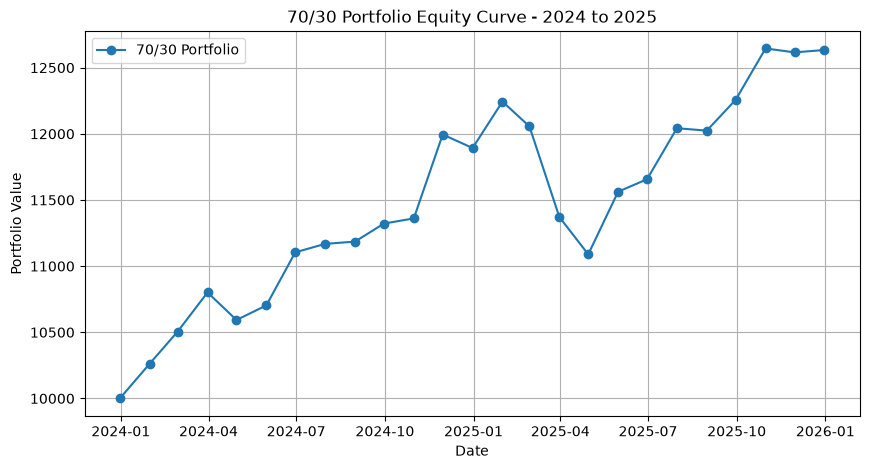

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    portfolio_equity.index,
    portfolio_equity,
    marker="o",
    label="70/30 Portfolio"
)

plt.title("70/30 Portfolio Equity Curve - 2024 to 2025")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.legend()
plt.show()

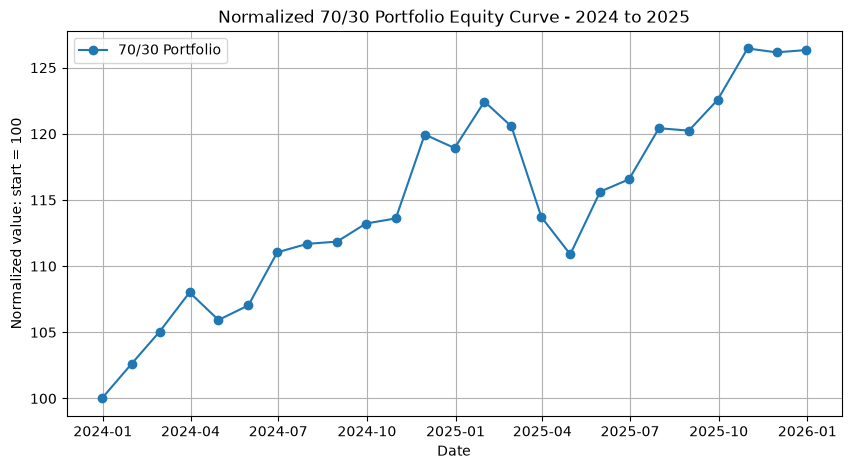

In [13]:
portfolio_equity_normalized = portfolio_equity / portfolio_equity.iloc[0] * 100

plt.figure(figsize=(10, 5))

plt.plot(
    portfolio_equity_normalized.index,
    portfolio_equity_normalized,
    marker="o",
    label="70/30 Portfolio"
)

plt.title("Normalized 70/30 Portfolio Equity Curve - 2024 to 2025")
plt.xlabel("Date")
plt.ylabel("Normalized value: start = 100")
plt.grid(True)
plt.legend()
plt.show()